In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df = df.iloc[:, 2:]

In [5]:
df.sample(5)

,Age,EstimatedSalary,Purchased
361,53,34000,1
391,47,23000,1
240,42,149000,1
266,40,75000,0
283,52,21000,1


In [6]:
# Train test split

from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop("Purchased", axis=1), df["Purchased"], test_size=0.3,random_state=0)

In [9]:
X_train.shape , X_test.shape

((280, 2), (120, 2))

In [10]:
# standard scaleer

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
scaler.mean_    

array([3.78642857e+01, 6.98071429e+04])

In [12]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)


X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)



In [13]:
np.round(X_train.describe(), 1)


,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [14]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


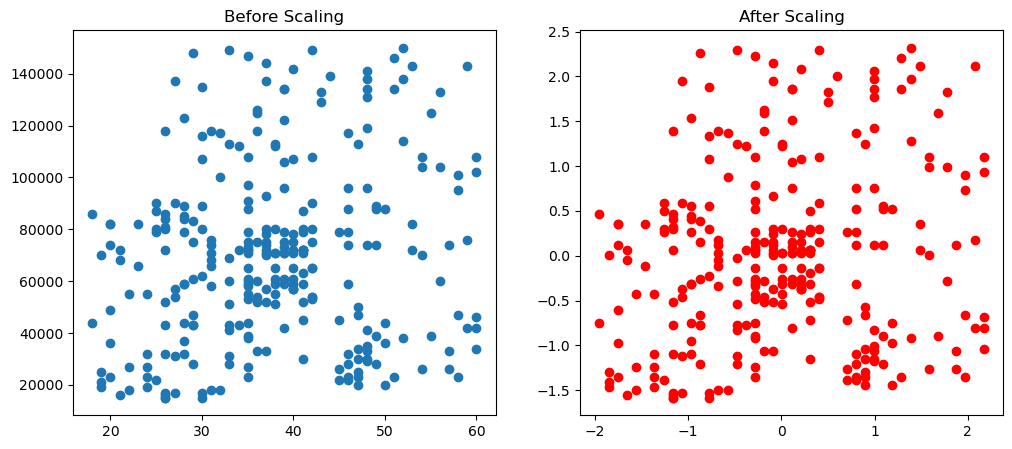

In [16]:
# effect of scaling

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_train["Age"], X_train["EstimatedSalary"])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled["Age"], X_train_scaled["EstimatedSalary"], color="red")

ax2.set_title("After Scaling")
plt.show()

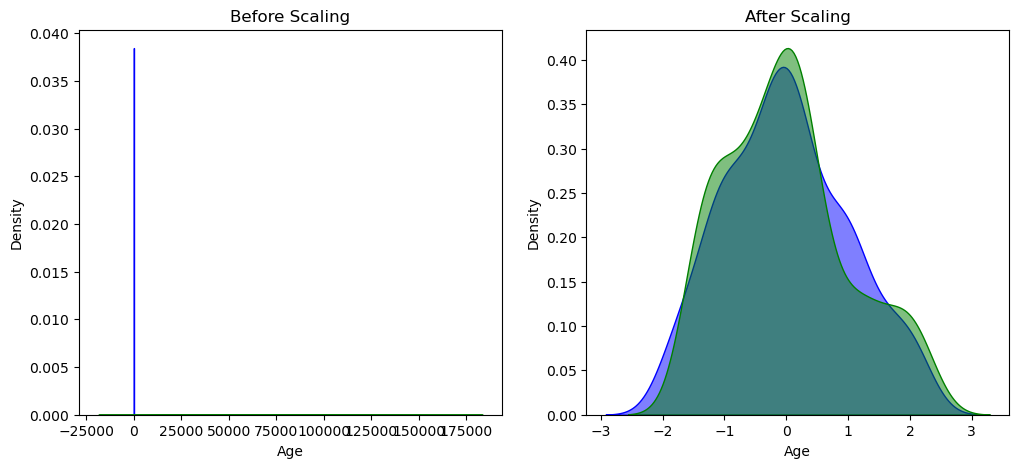

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"], ax=ax1, fill=True, color="blue", alpha=0.5)
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1, fill=True, color="green", alpha=0.5)

# after scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"], ax=ax2, fill=True, color="blue", alpha=0.5)
sns.kdeplot(X_train_scaled["EstimatedSalary"], ax=ax2, fill=True, color="green", alpha=0.5)
plt.show()

In [25]:
from sklearn.linear_model import LogisticRegression


In [26]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()


In [27]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)


LogisticRegression()

In [28]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [29]:
from sklearn.metrics import accuracy_score

In [30]:
print("Accuracy without Scaling:", accuracy_score(y_test, y_pred))
print("Accuracy with Scaling:", accuracy_score(y_test, y_pred_scaled))

Accuracy without Scaling: 0.875
Accuracy with Scaling: 0.8666666666666667
